In [1]:
# Customer Segmentation using RFM Analysis and K-Means Clustering

## Objective
###Segment customers based on purchasing behaviour using transaction data to identify high-value, loyal, and at-risk customers.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("online_retail.csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


(541909, 8)

In [5]:
#data cleaning

In [6]:
#removing missing customer IDs
df = df.dropna(subset=["CustomerID"])

In [7]:
#removing cancelled orders
df = df[~df["InvoiceNo"].astype(str).str.contains("C")]

In [8]:
#converting date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
#creating total price column
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [10]:
## RFM Feature Engineering

In [11]:
#creating snapshot date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [12]:
#RFM table
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "count",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [13]:
#normalizing data 
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

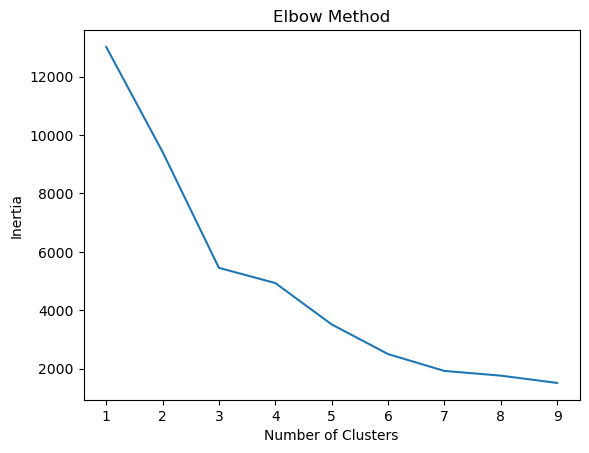

In [14]:
#Elbow Method
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [15]:
#Applying K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,1
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,3


In [16]:
#cluster profiling
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,20.89,135.48,2648.88
1,97.85,37.89,777.69
2,4.69,2566.00,126118.31
3,272.20,25.09,604.75


In [17]:
#segment naming
segment_map = {
0:"Loyal Customers",
1:"At Risk",
2:"Regular Customers",
3:"Champions"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Champions
12347.0,2,182,4310.00,0,Loyal Customers
12348.0,75,31,1797.24,1,At Risk
12349.0,19,73,1757.55,0,Loyal Customers
12350.0,310,17,334.40,3,Champions


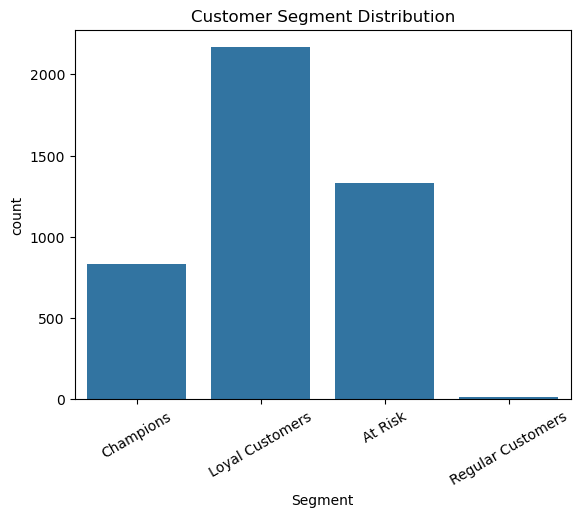

In [23]:
#Cluster Distribution Visualization
sns.countplot(x="Segment", data=rfm)
plt.xticks(rotation=30)
plt.title("Customer Segment Distribution")
plt.savefig("segment_distribution.png")
plt.show()

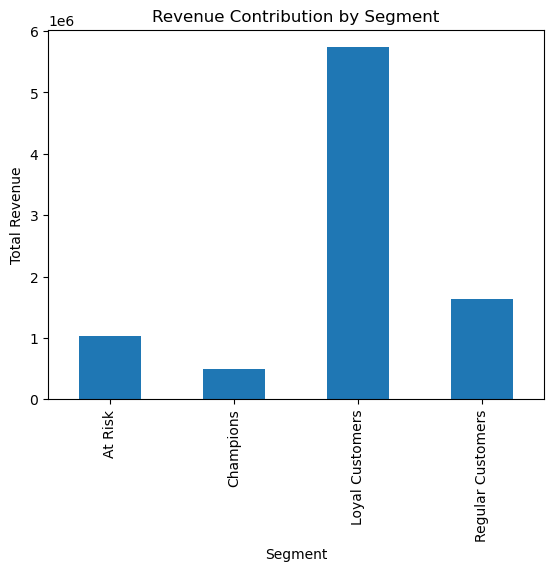

In [24]:
#Revenue by Segment
segment_revenue = rfm.groupby("Segment")["Monetary"].sum()

segment_revenue.plot(kind="bar")
plt.title("Revenue Contribution by Segment")
plt.ylabel("Total Revenue")
plt.savefig("revenue_by_segment.png")
plt.show()

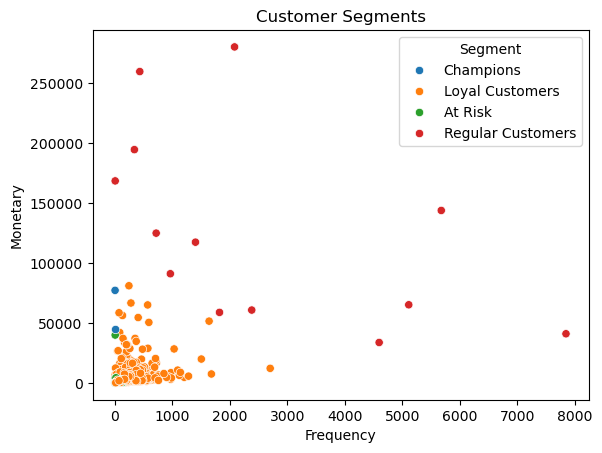

In [25]:
#Customer Behavior Scatter Plot
sns.scatterplot(
    x=rfm["Frequency"],
    y=rfm["Monetary"],
    hue=rfm["Segment"]
)

plt.title("Customer Segments")
plt.savefig("customer_behavior.png")
plt.show()

In [26]:
#Final segmented Dataset export
rfm.to_csv("customer_segments.csv")